In [2]:
import numpy as np
import pandas as pd

import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

# Вступление

В настоящей работе исследуется популярность музыкальных композиций (далее - треков) и её детерминанты на стриминговой платформе Spotify. В качестве наблюдений используются готовые данные, полученные с платформы kaggle (https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset). В массиве содержится информация о треках, авторах и различных характеристиках композиций начиная от жанра и заканчивая расчетными показателями Spotify (индекс популярности, "танцевальность", "инструментальность" и так далее). Центром исследования является популярность - индекс, рассчитываемый платформой.

In [3]:
df = pd.read_csv('dataset_genere.csv', encoding='ISO-8859-1')

# EDA

## Подготовка данных

In [4]:
df.head() # исходный массив данных

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
# удаление дубликатов и лишних столбцов

df.drop(['Unnamed: 0', 'track_id', 'album_name'], axis = 1, inplace = True)
df.drop_duplicates(subset=None, keep='first', inplace=True)

Были удалены следующие стобцы, так как они не будут использоваться в исследовании: 'Unnamed: 0', 'track_id', 'album_name' (было принято решенить удалить данную переменную, так как в данных есть треки с одинаковыми рассматриваемыми характеристиками, которые просто входят в несколько различных версий альбомов или переизданий синглов, то есть меняется только название альбома.

In [6]:
# пропуски в данных
df.isna().sum()

artists             1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
# посмотрим на наблюдения с пропущенными значениями
df[df.artists.isna()]

,artists,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [8]:
df.dropna(inplace = True) # удаление наблюдений с пропущенными значениями

Получается, что в исходных данных есть лишь одно наблюдение с пропущенными значениями названия трека и автора. Число пропусков мало, поэтому было принято решение удалить это наблюдение, так как пропущенны именно содержательно важные характеристики композиции.

In [9]:
df_mult_genre = df.copy()

# Список колонок для группировки (все кроме popularity и track_genre)
group_cols = ['artists', 'track_name', 'duration_ms', 'explicit', 'danceability', 
              'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 
              'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

# Сортируем по popularity 
df_sorted = df.sort_values('popularity', ascending=False)

# Группируем по уникальным признакам песни, собираем жанры и берем popularity первой строки (максимальное)
df = (df_sorted
            .groupby(group_cols, as_index=False)
            .agg({
                'track_genre': lambda x: list(set(x)),
                'popularity': 'first'}))

В исходном датасете присутствуют треки, относящиеся одновременно к нескольким музыкальным жанрам. В результате один и тот же трек представлен в данных как несколько наблюдений, различающихся значением переменной track_genre. Такое дублирование способно искажать оценку статистических характеристик выборки — средних значений, дисперсий, медиан, а также влиять на форму распределений и визуализации.

В связи с этим было принято решение агрегировать такие записи: каждому треку сопоставлено единое наблюдение, в котором переменная track_genre содержит список всех соответствующих жанров.

Следует отметить, что в данных также встречаются треки с одинаковым названием и составом исполнителей, отличающиеся по версии (explicit / implicit). Для таких записей объединение не применялось, поскольку версии трека не являются полностью идентичными объектами наблюдения. Наличие нецензурной лексики, например, представляет собой содержательное отличие, способное влиять на аудиторию и число прослушиваний. Таким образом, explicit- и implicit-версии рассматриваются как независимые наблюдения, каждое из которых может обладать собственным уровнем популярности.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83908 entries, 0 to 83907
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           83908 non-null  object 
 1   track_name        83908 non-null  object 
 2   duration_ms       83908 non-null  int64  
 3   explicit          83908 non-null  bool   
 4   danceability      83908 non-null  float64
 5   energy            83908 non-null  float64
 6   key               83908 non-null  int64  
 7   loudness          83908 non-null  float64
 8   mode              83908 non-null  int64  
 9   speechiness       83908 non-null  float64
 10  acousticness      83908 non-null  float64
 11  instrumentalness  83908 non-null  float64
 12  liveness          83908 non-null  float64
 13  valence           83908 non-null  float64
 14  tempo             83908 non-null  float64
 15  time_signature    83908 non-null  int64  
 16  track_genre       83908 non-null  object

## Обработка признаков, создание новых переменных

In [11]:
df['title_size'] = df.track_name.apply(len) # создание нового признака - длинна трека

df['explicit'] = df['explicit'] * 1 # дамми-переменная на содержание контента с возрастным ограничением 

df['duration'] = df['duration_ms'] / 60000 # перевод длительности треков из миллисекунд в минуты

In [12]:
df.drop('duration_ms', axis = 1, inplace = True) # удалим длительность в миллисекундах

Решение включить в модель новый признак duration, рассчитываемый как количество символов в названии трека (включая пробелы, знаки препинания и цифры), основано на следующем предположении: длинные названия могут труднее запоминаться, сложнее вводиться вручную и реже использоваться в рекомендациях между пользователями. Это, в свою очередь, потенциально снижает количество прослушиваний и может отрицательно влиять на популярность композиции.

Переменная explicit изначально имела логический тип данных, поэтому была преобразована в числовую дамми-переменную: значение 1 соответствует наличию метки explicit, значение 0 — её отсутствию.

Переменная duration_ms (длительность трека) была представлена в миллисекундах. Использование столь крупных числовых значений может затруднять интерпретацию оценённых коэффициентов модели и приводить к их численному занижению. С целью устранения этого эффекта значения длительности были преобразованы в минуты (1 минута = 60 000 миллисекунд), что обеспечивает более корректное масштабирование признака и улучшает интерпретируемость результатов моделирования.

In [13]:
df['num_artists'] = df['artists'].apply(lambda x: len(x.split(';'))) # число исполнителей трека

Также, был создан признак 'num_artists' - число исполнителей трека. Предполагается, что если число исполнителей больше 1, то трек привлекает большую аудиторию (от каждого участника), следовательно, это может приводить к росту прослушиваний и популярности композиции (положительная взаимосвзяь).

In [14]:
# Таблица с дискриптивными статистиками числовых переменных

num_columns = ['danceability', 'energy', 'key','loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'popularity', 'title_size', 'duration', 'num_artists']

discriptive_stats = pd.DataFrame({'mean': df[num_columns].mean(), 'median': df[num_columns].median(), 'st_div': df[num_columns].std(),
    'min': df[num_columns].min(), 'max': df[num_columns].max()})

discriptive_stats

,mean,median,st_div,min,max
danceability,0.559858,0.573000,0.177106,0.0000,0.98500
energy,0.635407,0.678000,0.258106,0.0000,1.00000
key,5.283143,5.000000,3.556696,0.0000,11.00000
loudness,-8.568988,-7.250000,5.274110,-49.5310,4.53200
mode,0.633599,1.000000,0.481824,0.0000,1.00000
speechiness,0.088466,0.049000,0.115526,0.0000,0.96500
acousticness,0.329075,0.189000,0.339592,0.0000,0.99600
instrumentalness,0.181568,0.000081,0.329380,0.0000,1.00000
liveness,0.219127,0.133000,0.197399,0.0000,1.00000
valence,0.465211,0.451000,0.263266,0.0000,0.99500


Следует отметить, что объём выборки является значительным (83 908 наблюдений), поэтому различия между средним и медианой для большинства переменных оказываются относительно небольшими.

Анализ описательной статистики числовых признаков позволяет заключить, что наибольшую вероятность наличия экстремальных значений демонстрируют переменные title_size, duration и num_artists. Эти признаки не отражают прямые музыкальные характеристики треков, и их максимальные значения превышают средние или медианные значения (с учётом стандартного отклонения) более чем в десять раз, что указывает на выраженную асимметрию распределений. Данные признаки требуют дополнительного анализа, в том числе визуального (гистограммы, боксплоты).

Некоторые переменные, описывающие «технические» характеристики композиций — danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, time_signature — также могут содержать значения, существенно отклоняющиеся от среднего. Однако классификация таких наблюдений как экстремальных или выбросов была бы в значительной степени субъективной. Это связано с тем, что данные признаки формируются на основе внутреннего алгоритма Spotify, методология которого не раскрывается, а также с тем, что значимые отклонения могут отражать реальные особенности музыкальных композиций. Поскольку целью работы является анализ факторов популярности, в первую очередь музыкально-акустических характеристик, исключение значений, определяемых визуально или субъективно как «аномальные», не представляется обоснованным.

Целевая переменная popularity ограничена диапазоном от 0 до 100, что делает её распределение естественным образом ограниченным. На основании анализа её разброса решений об исключении наблюдений также не принималось.

## Визуализация

### Классификация и обработка выбросов

In [15]:
df_disagg = df.explode('track_genre') # в данной выборке треки, которые принадлежат нескольким жанрам, рассматриваются как отдельные наблюдения

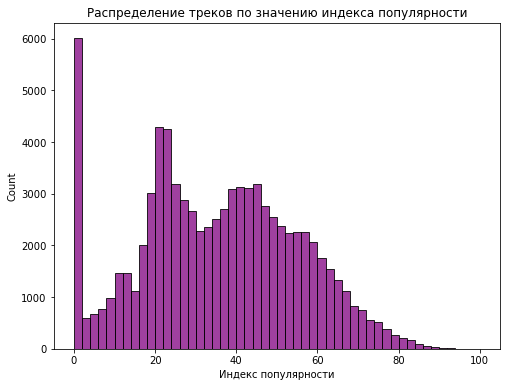

In [16]:
# график 1

plt.figure(figsize=(8,6))
sns.histplot(df.popularity, bins = 50, color = 'purple')
plt.xlabel('Индекс популярности')
plt.title('Распределение треков по значению индекса популярности')
plt.show()

Распределение треков по значению индекса популярности несимметрично, можно заметить, что большое число треков имеет достаточно низкие значения индекса. В целом, график 1 подтверждает, что число композиций с высокими оценками мало относительно общей массы, поэтому можно предположить, что такие треки обладают определенными свойствами. Визуально можно заключить, что значения индекса в основном сосредоточены вокруг следующих значений: 0, 20, 40 и 60.

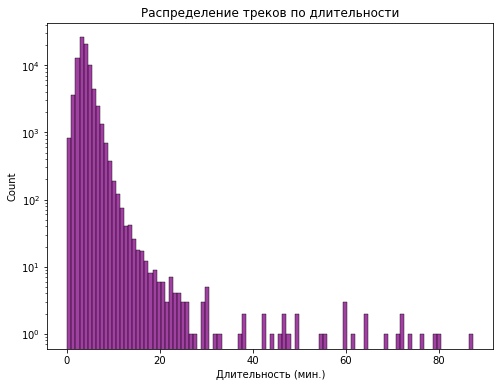

In [17]:
# график 2

plt.figure(figsize=(8,6))
sns.histplot(df.duration, bins = 100, color = 'purple', log_scale=(False, True))
plt.xlabel('Длительность (мин.)')
plt.title('Распределение треков по длительности')
plt.show()

Заметим, что распределение треков по длительности не обладает свойством симметричности, а основная масса наблюдений имеет значение данной переменной менее 25. Согласно данному графику, скорее всего, в данных действительно присутствуют выбросы - треки, длительность которых находится в диапазоне 30-88 минут. 

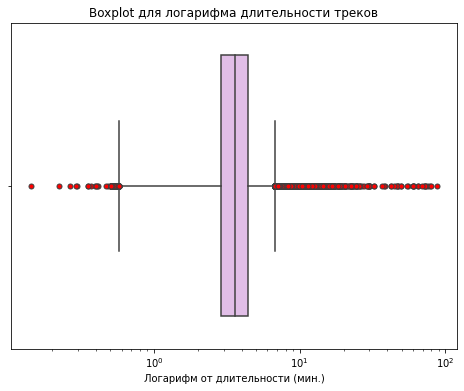

In [18]:
# график 3

plt.figure(figsize=(8,6))
sns.boxplot(x = df["duration"], boxprops = dict(facecolor="#E1BEE7"),           
    flierprops = dict(marker = 'o', color = 'red', markerfacecolor = 'red'))
plt.title('Boxplot для логарифма длительности треков')
plt.xlabel('Логарифм от длительности (мин.)')
plt.xscale('log')
plt.show()

На графике 3 длительность треков представлена в логарифмической шкале, что позволяет более наглядно визуализировать распределение и выявить экстремальные значения. Построенный boxplot подтверждает наличие выбросов: основная масса композиций имеет длительность приблизительно от 1.5 до 5.5 минут, что согласуется с интуитивными представлениями о типичной структуре популярной музыки.

Длительность трека может выступать значимым фактором, влияющим на его продвижение и последующую популярность. Так, радиостанции — один из ключевых внешних каналов распространения музыки наряду с социальными сетями, телевидением и сериалами — используют ограничения по максимально допустимой длительности композиций для включения их в ротацию. Более длинные треки также потенциально получают меньше прослушиваний в единицу времени, что напрямую отражается в стриминговой статистике и, соответственно, индексе популярности.

Кроме того, в условиях современной медиа-среды, характеризующейся быстрым потреблением контента, развитием коротких форматов и ориентацией на виральность, наблюдается устойчивая тенденция к сокращению длительности музыкальных произведений. В ряде случаев даже демо-версии или черновые варианты треков, опубликованные как часть творческого процесса, могут набирать значительные объёмы прослушиваний. Эти особенности подчеркивают релевантность включения длительности трека в анализ факторов популярности.

In [19]:
# число предполагаемых выбросов

df[df.duration >= 25].sort_values('popularity', ascending = False).shape[0]

45

Основываясь на изложенных выше соображениях, в данной работе предполагается классифицировать выбросы по длительности треков как наблюдения, превышающие верхнюю границу разумных значений, то есть чрезмерно продолжительные композиции. Следует отметить, что формальное определение критерия для выявления выбросов является методологически неоднозначной задачей и может решаться различными способами в зависимости от целей исследования и специфики данных.

В настоящем анализе, с целью минимизации потерь информации и сохранения репрезентативности выборки, было принято решение исключить из данных лишь те наблюдения, длительность которых превышает 25 минут. Такой подход можно считать практически безрисковым: количество композиций, длительность которых превышает указанное пороговое значение, составляет всего 45 единиц, что является крайне малой долей относительно общего объёма выборки. Таким образом, удаление данных треков не оказывает существенного влияния на итоговые результаты исследования.

In [20]:
# удаление выбросов на основе длительности треков

df = df[df.duration <= 25]

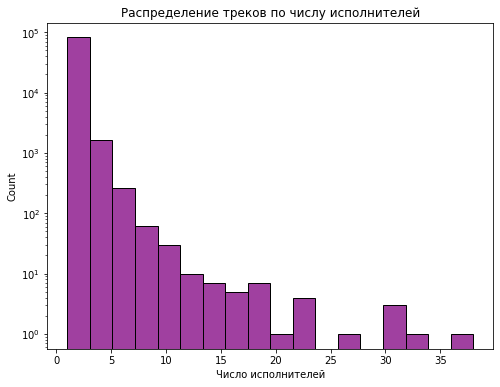

In [21]:
# график 4

plt.figure(figsize=(8,6))
sns.histplot(df['num_artists'], color = 'purple', log_scale=(False, True))
plt.xlabel('Число исполнителей')
plt.title('Распределение треков по числу исполнителей')
plt.show()

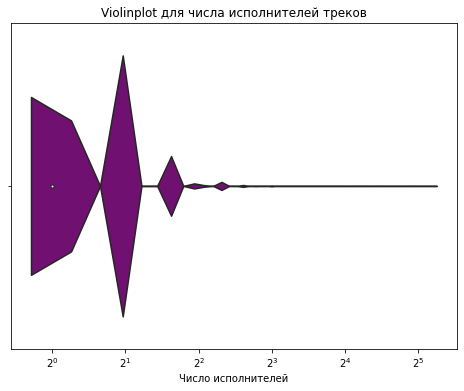

In [22]:
# график 5
plt.figure(figsize=(8,6))
sns.violinplot(data = df, x ='num_artists', color = 'purple')
plt.xscale('log', base=2)

plt.title('Violinplot для числа исполнителей треков')
plt.xlabel('Число исполнителей')
plt.show()

Согласно графику 4, распределение треков несимметрично, визуально не похоже на стандартные распределения (например, нормальное). Количество треков снижается с ростом числа исполнителей, а основная масса композиций имеет до 10 исполнителей.

На основе результатов графика 5 можно заключить, что в данных есть выбросы в контексте числа исполнителей. Максимальное значение данной переменной равно 38, что в разы превышает среднее и медиану. Число наблюдений, у которых число исполнителей превышает 10 мало, поэтому было принято решение удалить их, чтобы избежать возможные искажения результатов.

In [23]:
# число треков, у которых число исполнителей превышает 10 (выбросы)
df[df.num_artists > 10].shape[0]

50

In [24]:
# удаление выбросов на основе числа исполнителей 

df = df[df.num_artists <= 10]

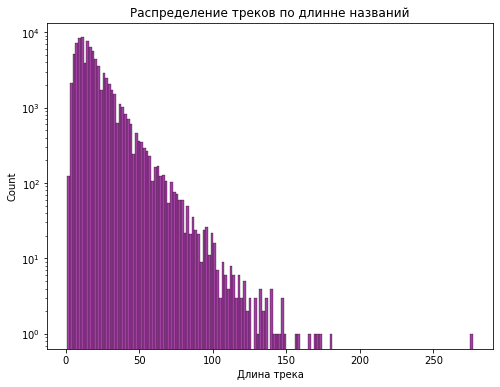

In [25]:
# график 6

plt.figure(figsize=(8,6))
sns.histplot(df["title_size"], bins = 150, color = 'purple', log_scale=(False, True))
plt.xlabel('Длина трека')
plt.title('Распределение треков по длинне названий')
plt.show()

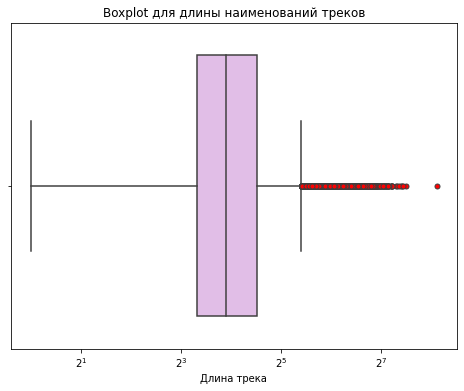

In [26]:
# график 7

plt.figure(figsize=(8,6))
sns.boxplot(x = df["title_size"], boxprops = dict(facecolor="#E1BEE7"),           
    flierprops = dict(marker = 'o', color = 'red', markerfacecolor = 'red'))
plt.title('Boxplot для длины наименований треков')
plt.xlabel('Длина трека')
plt.xscale('log', base = 2)
plt.show()

Согласно графику 6, распределение длины названий треков носит типичный для текстовых данных экспоненциально затухающий характер: преобладают короткие наименования (пик назодится в диапазоне 10-30 символов) , а длинные — редки, их частота убывает по мере роста числа символов. 

График 7 подтверждает наличие треков с экстримальными значениями переменной длинны названий. Заметим, начиная примерно с 60–80 символов, частота уже достаточно резко падает, а единичные случаи для больших длин (150+ символов) можно классифицировать как выбросы. На основе результатов графического анализа было принято решение удалить треки, длинна названий которых превышает 150 символов (таких треков 8).

In [27]:
# число треков,у которых переменная title_size превышает 150
df[df.title_size > 150].shape[0]

8

In [28]:
# удаление выбросов на основе title_size
df = df[df.title_size <= 150]

### Ключевые графики и формирование гипотез

Посмотрим на топ-10 треков по индексу популярности:

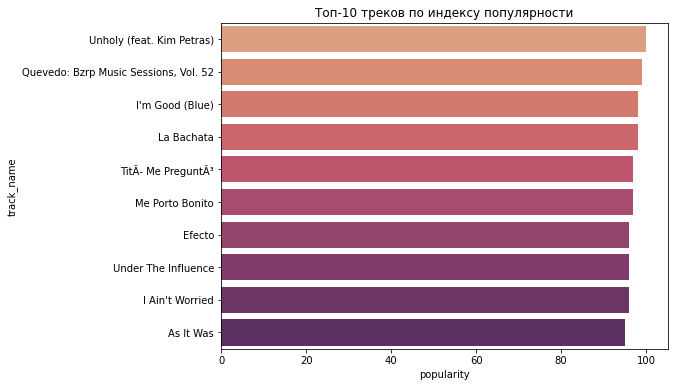

In [29]:
# график 8

plt.figure(figsize=(8,6))
top_10_songs = df.sort_values('popularity', ascending=False).head(10)[['track_name','artists','popularity']]

sns.barplot(data = top_10_songs,
            y = 'track_name',
            x = 'popularity', palette = 'flare')
plt.title('Топ-10 треков по индексу популярности')
plt.show()

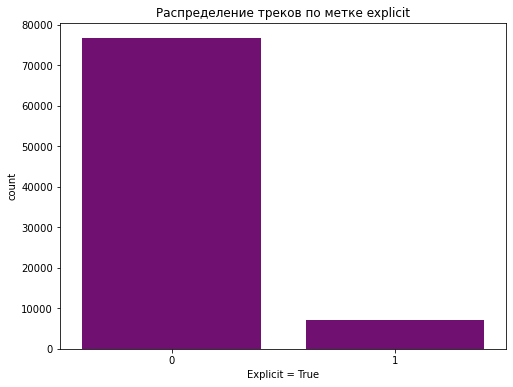

In [30]:
# график 9

plt.figure(figsize=(8,6))
sns.countplot(data = df, x = "explicit", color = 'purple')
plt.xlabel('Explicit = True')
plt.title('Распределение треков по метке explicit')
plt.show()

Видим (график 9), что абсолютное большинство треков не относится к категории explicit (explicit = False, 0), что вполне логично, так как таким образом исполнители, как минимум, обеспечивают себе большую аудиторию. Алгоритмы платформы не будут продвигать треки с меткой explicit несовершеннолетним детям, добавлять в праздничные плей-листы и так далее.

Ранее жанры по каждому треку объединялись в списки, но теперь нам необходимо снова разбить их на несколько наблюдений. Тем не менее, для проверки гипотезы о математическоим ожидании индекса популярности по жанрам необходима независимость выборок (спики треков по жанрам). Однако, если один трек принадлежит к более, чем 1 жанру, то попадает в несколько сравниваемых выборок, что ведет к нарушению их независимости. Как следствие, результаты статистических тестов становятся некорректными. 

Так как число треков, принадлежщих лишь одному жанру, велико (69872), было принято решение не использовать для анализа треки, принадлежащие нескольким жанрам. После данного преобразования число уникальных жанров составило 112.

In [31]:
df_one_genre = df[df['track_genre'].apply(lambda x: len(x) == 1)].explode('track_genre').copy()
df_one_genre

,artists,track_name,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity,title_size,duration,num_artists
0,!nvite,pagadoff,0,0.784,0.657,11,-7.591,0,0.3480,0.332,0.00362,0.1310,0.501,84.997,4,study,5,8,2.264333,1
1,!nvite,strolling,0,0.857,0.381,2,-12.755,1,0.1920,0.666,0.01910,0.1260,0.329,84.997,4,study,41,9,2.314583,1
2,"""Puppy Dog Pals"" Cast",Going on a Mission,0,0.629,0.776,7,-3.839,0,0.0470,0.021,0.00000,0.0930,0.957,93.937,3,children,55,18,0.635733,1
3,"""Puppy Dog Pals"" Cast",Puppy Dog Pals Main Title Theme,0,0.781,0.936,3,-4.709,1,0.2020,0.171,0.00141,0.2020,0.873,182.148,4,children,60,31,0.963150,1
4,"""Weird Al"" Yankovic","Amish Paradise (Parody of ""Gangsta's Paradise""...",0,0.728,0.448,8,-10.540,1,0.1720,0.103,0.00000,0.2670,0.483,80.902,4,comedy,58,57,3.382000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83903,é»å¦,æº«æçæå¨,0,0.549,0.450,10,-7.176,0,0.0251,0.461,0.00000,0.1030,0.234,90.062,3,mandopop,23,15,4.856667,1
83904,é»å°ç¥,æ²é£éº½ç°¡å®,0,0.334,0.431,6,-5.861,1,0.0347,0.672,0.00000,0.1010,0.212,201.701,3,mandopop,56,15,5.168883,1
83905,é»æè¯,å ¤å²¸,0,0.549,0.478,0,-6.186,1,0.0276,0.783,0.00000,0.2550,0.341,125.917,4,cantopop,20,6,3.645550,1
83906,é¾èRyuzo,ã²ã²ã²ã®é¬¼å¤ªé (Instrumental),0,0.571,0.325,7,-11.442,1,0.0443,0.404,0.41700,0.0872,0.320,116.457,3,guitar,23,36,2.802283,1


In [32]:
# суммарное число жанров
len(df_one_genre.explode('track_genre')['track_genre'].unique())

112

In [33]:
# жанр с минимальным числом треков в выборке
df_one_genre.explode('track_genre').groupby('track_genre').size().reset_index(name = 'num_tracks_per_genre').min()

track_genre             acoustic
num_tracks_per_genre          67
dtype: object

In [34]:
# жанр с максимальным числом треков в выборке
df_one_genre.explode('track_genre').groupby('track_genre').size().reset_index(name = 'num_tracks_per_genre').max()

track_genre             world-music
num_tracks_per_genre            996
dtype: object

In [35]:
# среднее число треков по каждому жанру
df_one_genre.explode('track_genre').groupby('track_genre').size().reset_index(name = 'num_tracks_per_genre').num_tracks_per_genre.mean()

623.8571428571429

Можно заключить, что в данных есть небольшой дисбаланс с точки зрения числа треков по каждому жанру. Однако далее будут проверены гипотезы, которые будут корректны с точки зрения методологии  и в этих условиях.

In [36]:
# в df_genre содержится информация о среднем значении индекса популярности по жанрам
df_genre = df_one_genre.explode('track_genre').groupby('track_genre')['popularity'].mean().reset_index(name = 'mean_popularity').sort_values('mean_popularity', ascending=False)
df_genre

,track_genre,mean_popularity
65,k-pop,59.063969
71,metal,59.040816
81,pop-film,56.726115
15,chill,56.112281
80,pop,55.653595
...,...,...
42,grindcore,14.520325
13,chicago-house,12.159529
24,detroit-techno,11.025614
93,romance,3.565315


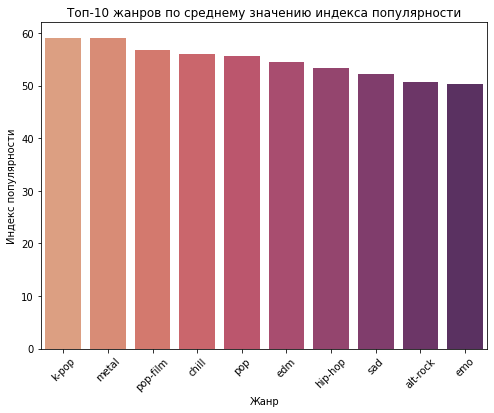

In [37]:
# график 10
plt.figure(figsize=(8,6))
sns.barplot(x = df_genre.track_genre[:10], y = df_genre.mean_popularity, palette = 'flare')
plt.xticks(rotation=45)
plt.xlabel('Жанр')
plt.ylabel('Индекс популярности')
plt.title('Топ-10 жанров по среднему значению индекса популярности')
plt.show()

Согласно графику 10, наивысшей популярностью обладают треки жанра k-pop, а на втором и третьем месте - metal и pop-film соотвественно. Далее по убыванию следуют chill и pop, затем edm, hip-hop, sad, alt-rock, indian и emo. Разница между жанрами k-pop и metal в верхней части рейтинга относительно невелика: их средние значения индекса популярности расположены близко друг к другу, что говорит о сопоставимом уровне интереса аудитории. Далее, проверим гипотезы 1-2 о равенстве математических ожиданий и дисперсий индекса популярности по этим двум жанрам соотвественно (равны ли распределения).

Таким образом, в рассматриваемом датасете наиболее популярными являются поп‑жанры, тогда как альтернативные или нишевые направления демонстрируют меньшую среднюю популярность, хотя и входят в топ‑10.

Интуитивно кажется, что поп-музыка более динамична/ритмична, чем метал, то есть под песни pop удобнее танцевать, следовательно значение переменной danceability выше. 

Посмотрим, так ли это, построив распределения переменной danceability по этим жанрам:

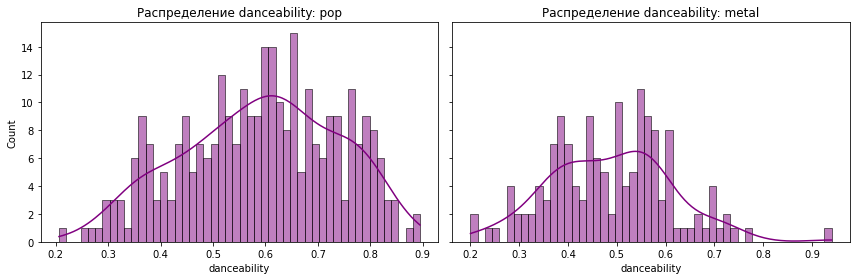

In [38]:
# графики 11-12
genres = ['pop', 'metal']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, g in zip(axes, genres):
    sns.histplot(
        data = df_one_genre[df_one_genre['track_genre'] == g],
        x = 'danceability',
        bins = 50,
        kde = True,
        ax = ax, color = 'purple')
    ax.set_title(f'Распределение danceability: {g}')
    ax.set_xlabel('danceability')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

В целом, можно заключить, что сформулированные выше предположения подстверждаются, как минимум, графически. Согласно графкам 11-12, треки жанра pop обладают более высокими значениями переменной danceability, чем треки жанра metal. 

Для более формального подтверждения проверим гипотезу №3: математическое ожидание переменной danceability у треков жанра pop больше математического ожидания данной переменной у треков жанра metal.

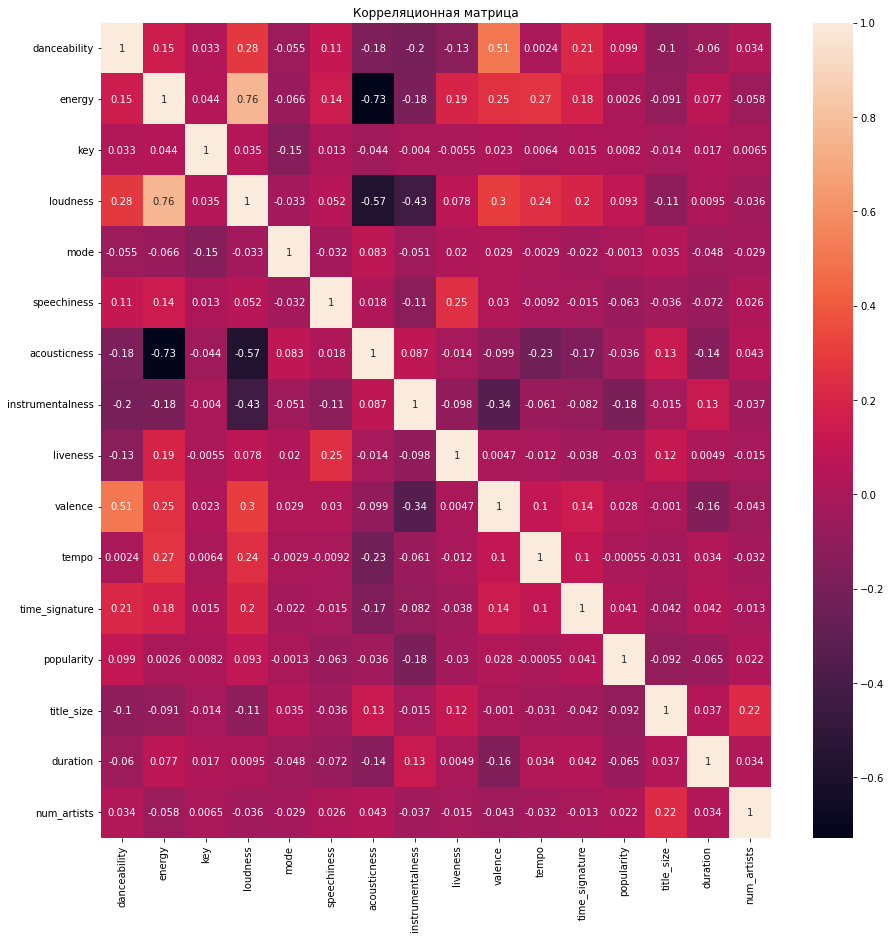

In [39]:
# график 13
plt.figure(figsize=(15,15))
columns_num = ['danceability', 'energy', 'key','loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'popularity', 'title_size', 'duration', 'num_artists']

sns.heatmap(df_one_genre[columns_num].corr(method='pearson'),  annot=True)
plt.title('Корреляционная матрица')
plt.show()

Можно заключить, что сильных линейных зависимостей между признаками практически нет (но, возможно, есть нелинейные).


Большинство коэффициентов корреляции находятся в диапазоне от –0.3 до 0.3, что указывает на слабые связи. 
Выделяется только одна ярко выраженная отрицательная связь:

energy — acousticness (примерно –0.73).

Энергичные треки, как правило, обладают низкой акустичностью. Такая связь отражает реальные особенности музыкального производства.

Наблюдаются несколько умеренных зависимостей:

loudness — energy (примерно 0.57): более энергичные треки обычно громче.

danceability — valence (примерно 0.51): танцевальные треки чаще обладают более «позитивным» настроем.

loudness — acousticness (примерно –0.57): акустические треки, как правило, менее громкие.

Популярность практически не коррелирует с аудиохарактеристиками трека.
Все коэффициенты находятся в диапазоне примерно от –0.06 до 0.09.
Это указывает на отсутствие выраженных линейных закономерностей между популярностью и техническими характеристиками композиции (можно предположить, что популярность сильнее зависит от прочих факторов, личный бренд, продвижение в соц. сетях, "виральность" и так далее).

Линейная взаимосвязь переменных не велика в целом, поэтому проблема мультиколлинеарности отсутсвует.